# LOSO CV: Daily Batch SGD with Seasonal Interaction Kernel

Each training epoch samples **1 complete day** of data (~21 observations
covering all monitoring sites). This preserves full spatial structure within
each batch — the model learns spatial patterns with temporal variation
controlled. Over hundreds of epochs, the model sees many different days.

Follows Patel et al. (2022, AAAI) time-split batching strategy.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`

**Best configuration:** 1 day/epoch, 200 inference days, patience=30

In [1]:
import subprocess
import sys
import time

cmd = [
    sys.executable, 'loso_cv_parallel.py',
    '--n_days', '1',
    '--n_epochs', '1000',
    '--patience', '30',
    '--inference_days', '200',
    '--prefix', 'daily',
    '--n_gpus', '8',
]
print(f"Running: {' '.join(cmd)}")
start = time.perf_counter()
result = subprocess.run(cmd, capture_output=True, text=True)
elapsed = time.perf_counter() - start
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
print(f"Script finished in {elapsed:.1f}s")

Running: /home/vcaristo/miniconda3/envs/patel/bin/python loso_cv_parallel.py --n_days 1 --n_epochs 1000 --patience 30 --inference_days 200 --prefix daily --n_gpus 8


Configuration: n_gpus=8, n_epochs=1000, patience=30
Batching: daily (1 day(s)/epoch)
Inference: 200 days
Available CUDA devices: 4
Using 4 GPUs

15,572 observations, 32 sites, 730 unique dates
Avg 21.3 obs/day → ~21 obs/batch

Launching 32 folds across 4 GPUs...
  Fold  2 (GPU 2) site=114158_46244: R²=-0.034, epochs=62, avg_batch=20, train=1.2s
  Fold  1 (GPU 1) site=114021_46842: R²=-0.079, epochs=104, avg_batch=20, train=1.9s
  Fold  0 (GPU 0) site=115553_48392: R²=0.349, epochs=110, avg_batch=20, train=2.0s
  Fold  3 (GPU 3) site=115324_47594: R²=0.294, epochs=114, avg_batch=21, train=2.0s
  Fold  4 (GPU 0) site=112501_46003: R²=-0.012, epochs=105, avg_batch=21, train=1.6s
  Fold  6 (GPU 2) site=112013_46659: R²=0.249, epochs=74, avg_batch=20, train=1.2s
  Fold  5 (GPU 1) site=111092_44658: R²=-0.150, epochs=121, avg_batch=20, train=1.6s
  Fold  7 (GPU 3) site=111303_47494: R²=0.227, epochs=135, avg_batch=21, train=1.9s
  Fold  8 (GPU 0) site=111056_45684: R²=-1.707, epochs=98, avg_

## Results

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('daily_results.json') as f:
    results = json.load(f)

metrics_df = pd.read_csv('daily_site_metrics.csv')
params_df = pd.read_csv('daily_kernel_params.csv')
timing_df = pd.read_csv('daily_fold_timings.csv')
data = np.load('daily_predictions.npz')

print('=' * 60)
print('LOSO CV Results (Daily Batch SGD, Seasonal Interaction)')
print('=' * 60)
o = results['overall']
c = results['config']
print(f"Training: {c['training']}, n_days={c['n_days']}, patience={c['patience']}")
print(f"Inference: {c['inference_days']} days ({timing_df['n_infer_points'].mean():.0f} points)")
print(f"Log scale:  RMSE={o['rmse_log']:.4f}, MAE={o['mae_log']:.4f}, R²={o['r2_log']:.4f}")
print(f"Orig scale: RMSE={o['rmse_orig']:.2f}, MAE={o['mae_orig']:.2f}, R²={o['r2_orig']:.4f}")
print(f"Total time: {o['total_time']:.1f}s")
print()
print("Batch structure:")
print(f"  Avg batch size: {timing_df['avg_batch_size'].mean():.0f} obs/epoch")
print(f"  Stopped epochs: mean={timing_df['stopped_epoch'].mean():.0f}, "
      f"min={timing_df['stopped_epoch'].min()}, max={timing_df['stopped_epoch'].max()}")
print()
print("Site-level R² summary:")
print(metrics_df['r2_log'].describe())

LOSO CV Results (Daily Batch SGD, Seasonal Interaction)
Training: daily_batch_sgd, n_days=1, patience=30
Inference: 200 days (4115 points)
Log scale:  RMSE=0.6100, MAE=0.4714, R²=0.3257
Orig scale: RMSE=5.53, MAE=3.32, R²=0.3426
Total time: 19.5s

Batch structure:
  Avg batch size: 21 obs/epoch
  Stopped epochs: mean=95, min=62, max=140

Site-level R² summary:
count    32.000000
mean     -1.683096
std       9.670268
min     -54.581209
25%      -0.089145
50%       0.226846
75%       0.340356
max       0.547525
Name: r2_log, dtype: float64


## Training Loss

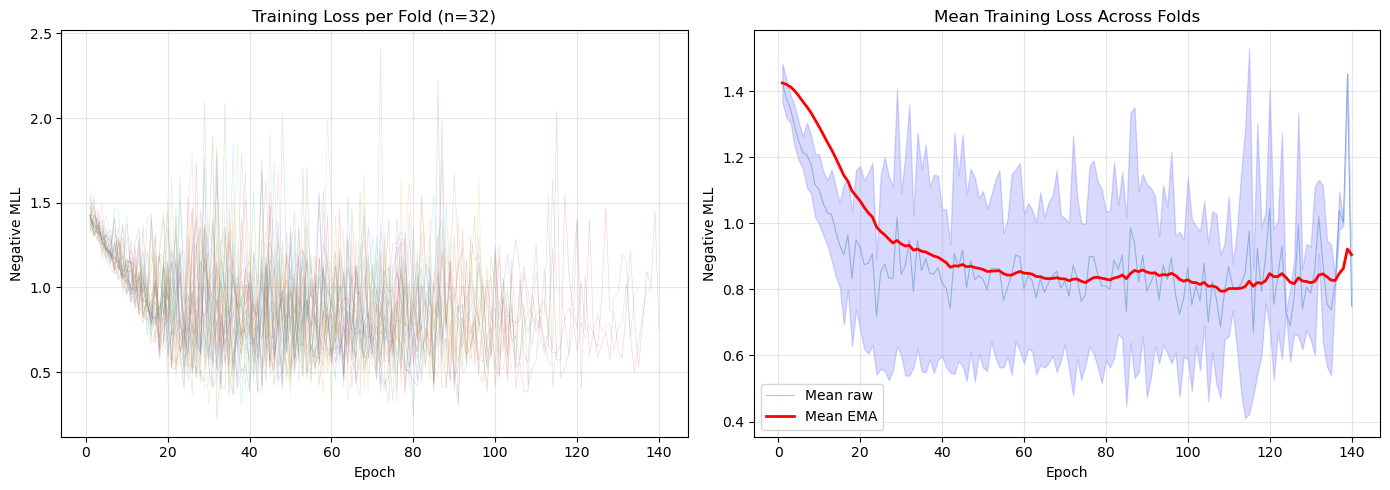

Min mean raw loss at epoch 116: 0.6705
Final EMA: 0.9053


In [3]:
fold_losses = results['fold_losses']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for site, losses in fold_losses.items():
    axes[0].plot(range(1, len(losses)+1), losses, alpha=0.2, linewidth=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL')
axes[0].set_title(f'Training Loss per Fold (n={len(fold_losses)})')
axes[0].grid(True, alpha=0.3)

max_len = max(len(v) for v in fold_losses.values())
loss_matrix = np.full((len(fold_losses), max_len), np.nan)
for i, losses in enumerate(fold_losses.values()):
    loss_matrix[i, :len(losses)] = losses
mean_loss = np.nanmean(loss_matrix, axis=0)
std_loss = np.nanstd(loss_matrix, axis=0)
epochs = np.arange(1, len(mean_loss)+1)

ema = [mean_loss[0]]
for l in mean_loss[1:]:
    ema.append(0.9 * ema[-1] + 0.1 * (l if not np.isnan(l) else ema[-1]))

axes[1].plot(epochs, mean_loss, alpha=0.4, linewidth=0.8, label='Mean raw')
axes[1].plot(epochs[:len(ema)], ema, 'r-', linewidth=2, label='Mean EMA')
axes[1].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                     alpha=0.15, color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL')
axes[1].set_title('Mean Training Loss Across Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

min_epoch = np.nanargmin(mean_loss) + 1
print(f'Min mean raw loss at epoch {min_epoch}: {np.nanmin(mean_loss):.4f}')
print(f'Final EMA: {ema[-1]:.4f}')

## Predictions

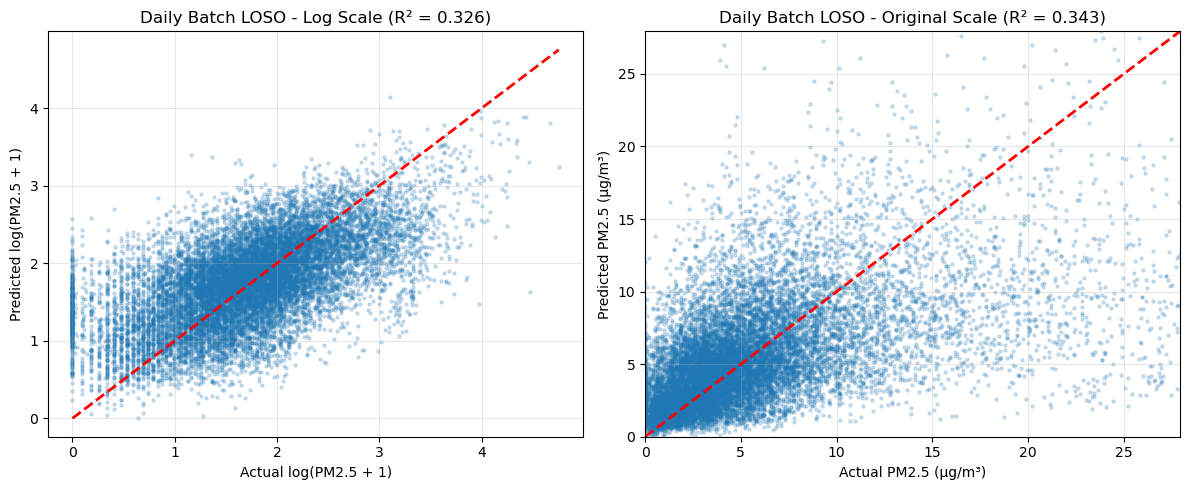

In [4]:
all_pred = data['predictions']
all_actual = data['actuals']
pred_pm25 = data['pred_pm25']
actual_pm25 = data['actual_pm25']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actual, all_pred, alpha=0.2, s=5)
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Daily Batch LOSO - Log Scale (R² = {o["r2_log"]:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'Daily Batch LOSO - Original Scale (R² = {o["r2_orig"]:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Site-Level Analysis

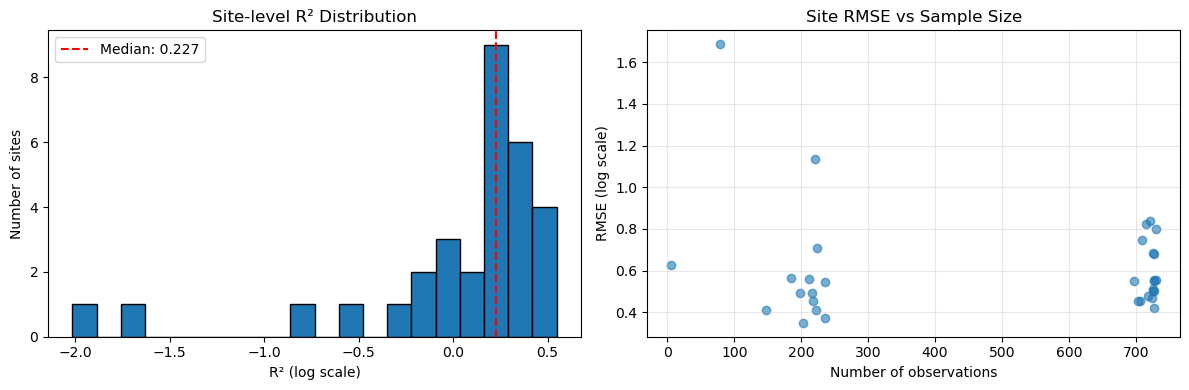

Top 5 best sites:
        site  n_obs  rmse_log   r2_log
115672_47955    218  0.454728 0.547525
106557_45648    235  0.370503 0.518993
108720_47582    222  0.410018 0.511237
111712_46826    147  0.413221 0.504825
106490_45366    707  0.453826 0.394322

Top 5 worst sites:
        site  n_obs  rmse_log     r2_log
115195_48971     78  1.686160 -54.581209
113997_48510    221  1.134669  -2.014380
111056_45684    710  0.745705  -1.707199
112364_48607    185  0.562652  -0.838198
109677_48551    203  0.349769  -0.596619


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid_r2 = metrics_df['r2_log'].dropna()
axes[0].hist(valid_r2[valid_r2 > -5], bins=20, edgecolor='black')
axes[0].axvline(x=valid_r2.median(), color='r', linestyle='--',
                label=f'Median: {valid_r2.median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R² Distribution')
axes[0].legend()

axes[1].scatter(metrics_df['n_obs'], metrics_df['rmse_log'], alpha=0.6)
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Top 5 best sites:')
print(metrics_df.nlargest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))
print()
print('Top 5 worst sites:')
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

## Kernel Parameters

In [6]:
print('Learned kernel output scales:')
print(f"{'Component':<25} {'Mean':>8} {'Std':>8}")
print('-' * 45)
for col, label in [('base_scale', 'Base RBF_ARD'),
                    ('summer_scale', 'AOT x Season'),
                    ('winter_scale', 'SmogI/P x Season'),
                    ('seasonal_scale', 'Residual Seasonal')]:
    print(f'{label:<25} {params_df[col].mean():>8.4f} {params_df[col].std():>8.4f}')

print()
print('Learned periods (days):')
for col, label in [('aot_period_days', 'AOT periodic'),
                    ('smog_period_days', 'Smog periodic'),
                    ('residual_period_days', 'Residual periodic')]:
    print(f'{label:<25} {params_df[col].mean():>8.1f} {params_df[col].std():>8.1f}')

Learned kernel output scales:
Component                     Mean      Std
---------------------------------------------
Base RBF_ARD                0.1205   0.0286
AOT x Season                0.0416   0.0222
SmogI/P x Season            0.3343   0.0563
Residual Seasonal           0.1006   0.0922

Learned periods (days):
AOT periodic                 365.2      0.0
Smog periodic                365.2      0.0
Residual periodic            365.2      0.0
